<a href="https://colab.research.google.com/github/AtulMomre2327/Intro-to-Machine-Learning/blob/main/Cross_Validation_%26_Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <b> <u>Problem Statement</u></b>

### A Chinese automobile company Geely Auto aspires to enter the US market by setting up their manufacturing unit there and producing cars locally to give competition to their US and European counterparts.

### They have contracted an automobile consulting company to understand the factors on which the pricing of cars depends. Specifically, they want to understand the factors affecting the pricing of cars in the American market, since those may be very different from the Chinese market. The company wants to know:

* ### Which variables are significant in predicting the price of a car
* ### How well those variables describe the price of a car
* ### Based on various market surveys, the consulting firm has gathered a large data set of different types of cars across the America market.

# <b><u> Business Goal</u></b>
### We are required to model the price of cars with the available independent variables. It will be used by the management to understand how exactly the prices vary with the independent variables. They can accordingly manipulate the design of the cars, the business strategy etc. to meet certain price levels. Further, the model will be a good way for management to understand the pricing dynamics of a new market.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importing the dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Toppers Acadmy Data/data/Machine Learning/Chapter 1:- ML Appetizer/Day 6/Copy of CarPrice_project.csv')

In [ ]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


# <b>DataSet Information:</b>

Car_ID: Unique id of each observation (Interger)

Symboling: Its assigned insurance risk rating, A value of +3 indicates that the auto is risky, -3 that it is probably pretty safe.(Categorical)

CarName: Name of car company (Categorical)

fueltype: Car fuel type i.e gas or diesel (Categorical)

aspiration: Aspiration used in a car (Categorical)

doornumber: Number of doors in a car (Categorical)

carbody: body of car (Categorical)

drivewheel: type of drive wheel (Categorical)

enginelocation: Location of car engine (Categorical)

wheelbase: Weelbase of car (Numeric)

carlength: Length of car (Numeric)

carwidth: Width of car (Numeric)

carheight: height of car (Numeric)

curbweight: The weight of a car without occupants or baggage. (Numeric)

enginetype: Type of engine. (Categorical)

cylindernumber: cylinder placed in the car (Categorical)

enginesize: Size of car (Numeric)

fuelsystem: Fuel system of car (Categorical)

boreratio: Boreratio of car (Numeric)

stroke: Stroke or volume inside the engine (Numeric)

compressionratio: compression ratio of car (Numeric)

horsepower: Horsepower (Numeric)

peakrpm: car peak rpm (Numeric)

citympg: Mileage in city (Numeric)

highwaympg: Mileage on highway (Numeric)

price(Dependent variable): Price of car (Numeric)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [ ]:
df.describe().columns

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [ ]:
numeric_features = df[df.describe().columns]
numeric_features.head()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0


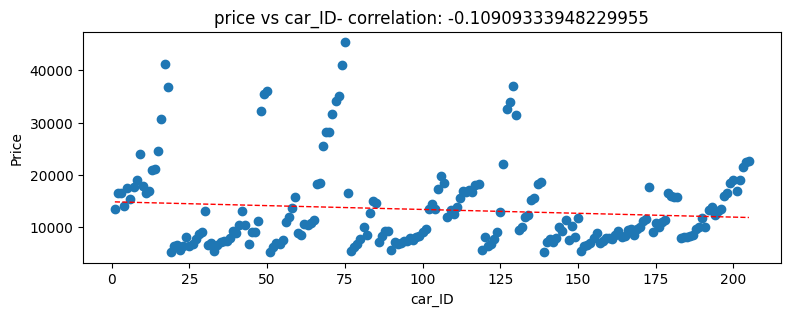

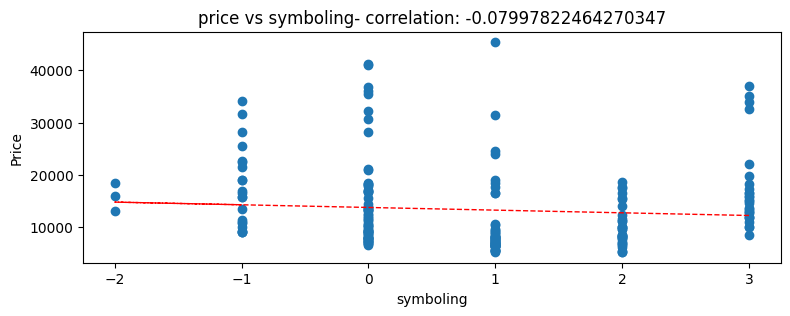

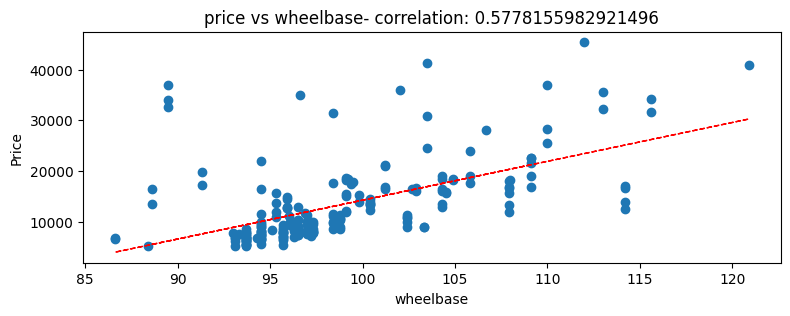

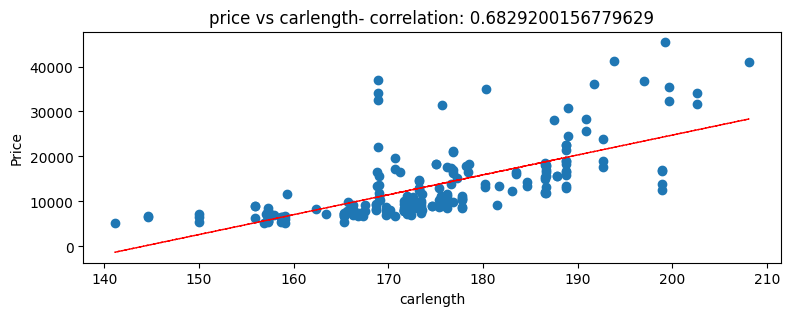

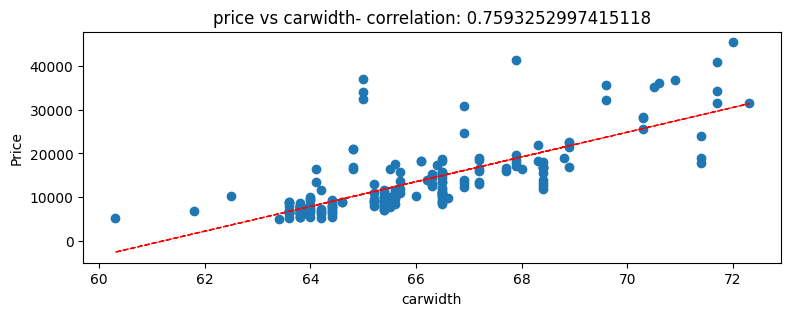

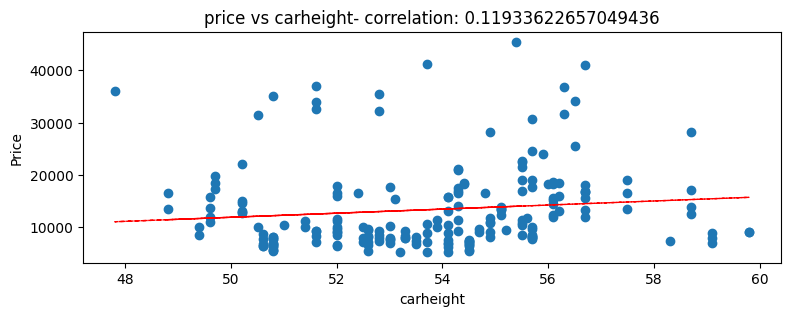

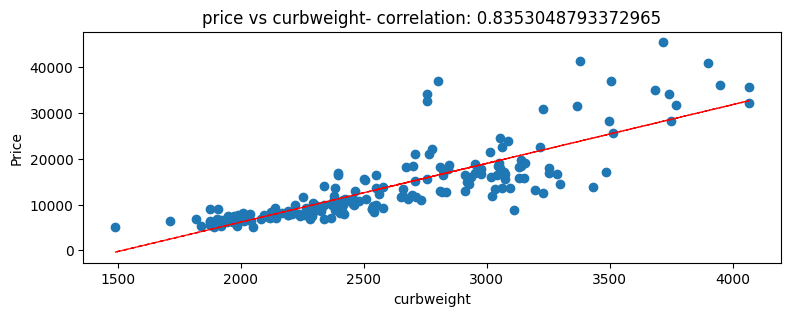

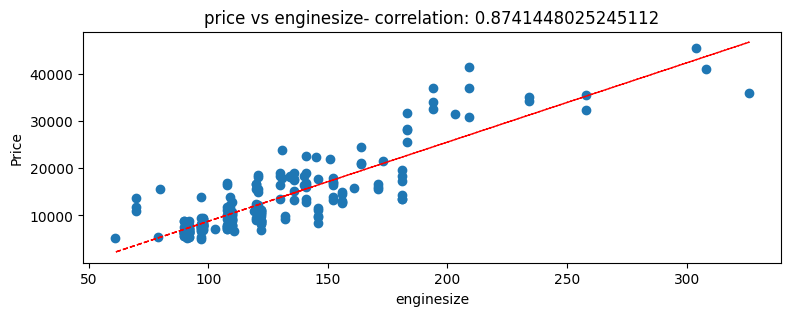

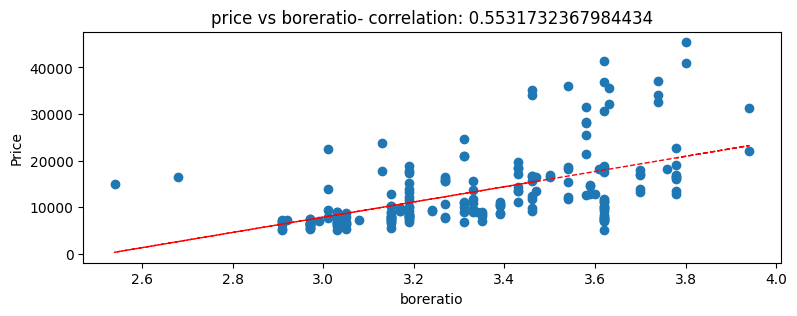

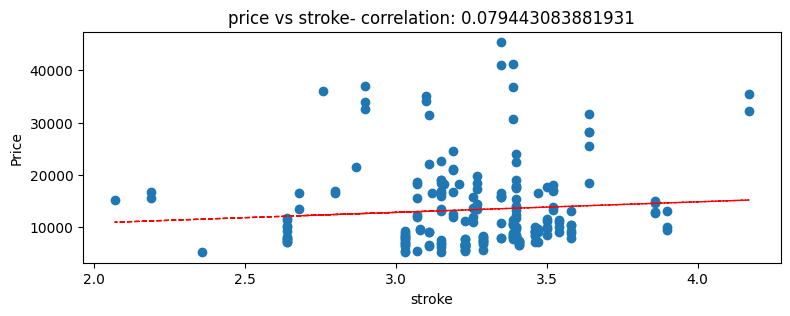

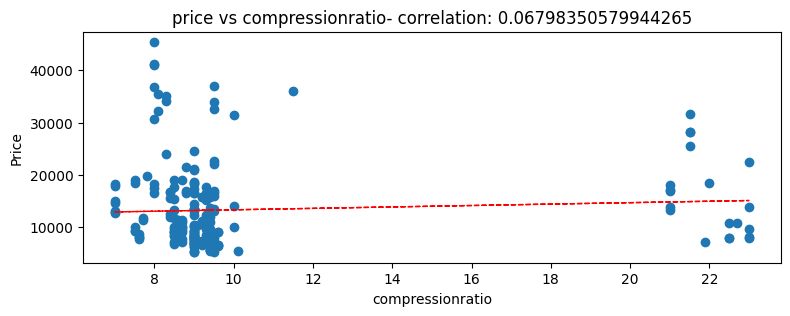

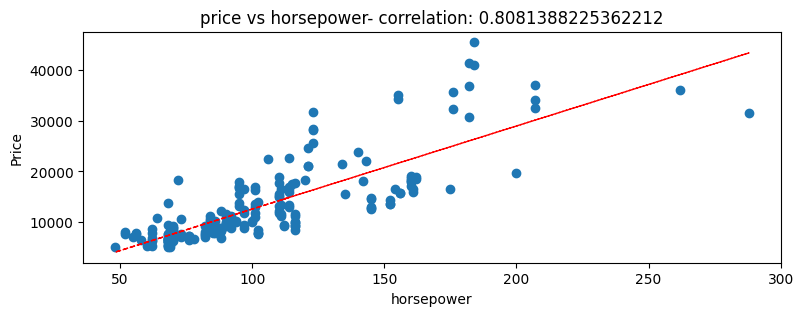

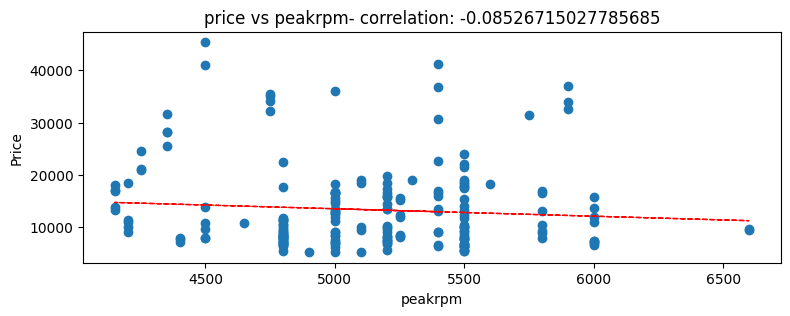

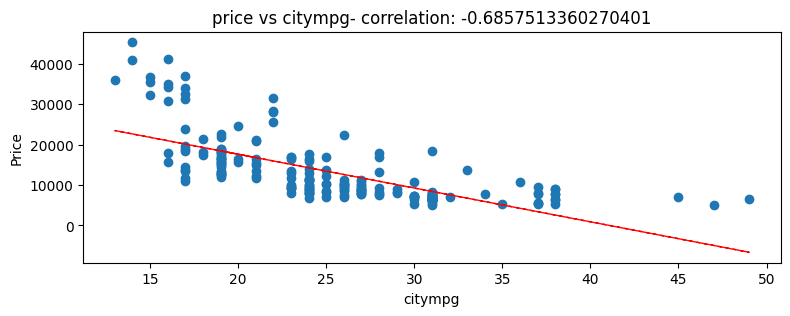

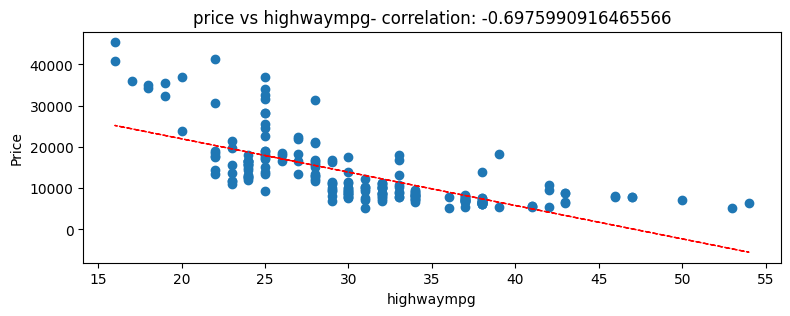

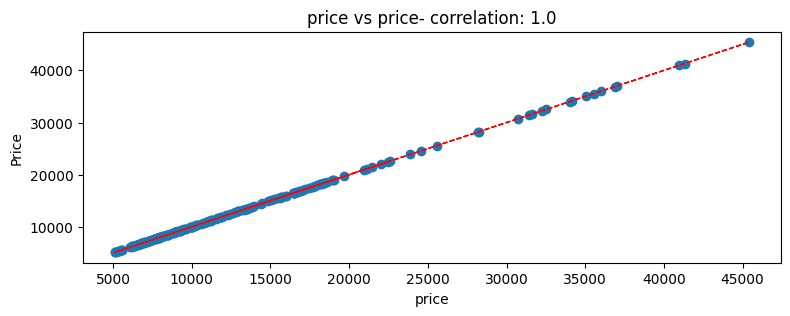

In [ ]:
for col in numeric_features[1:-1]:
    fig = plt.figure(figsize=(9, 3))
    ax = fig.gca()
    feature = df[col]
    label = df['price']
    correlation = feature.corr(label)
    plt.scatter(x=feature, y=label)
    plt.xlabel(col)
    plt.ylabel('Price')
    ax.set_title('price vs ' + col + '- correlation: ' + str(correlation))
    z = np.polyfit(df[col], df['price'], 1)
    y_hat = np.poly1d(z)(df[col])

    plt.plot(df[col], y_hat, "r--", lw=1)

plt.show()

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

<Axes: >

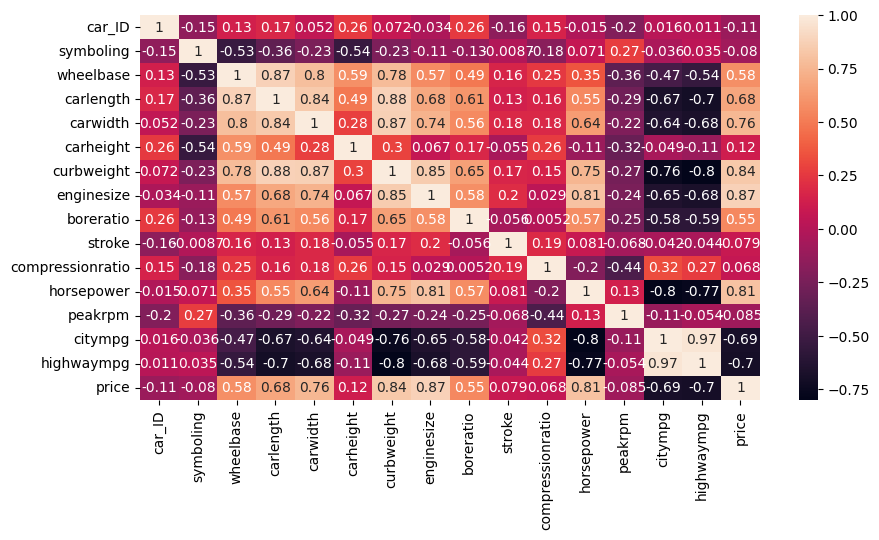

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(numeric_features.corr(),annot = True)

In [ ]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [ ]:
df.drop(columns = ['car_ID'],inplace = True)

In [ ]:
df.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df['cylindernumber'].value_counts()

,count
cylindernumber,
four,159
six,24
five,11
eight,5
two,4
twelve,1
three,1


In [ ]:
# Column encoding
df = pd.get_dummies(df,columns = ['fueltype','fuelsystem','cylindernumber','enginetype','enginelocation','drivewheel','carbody','doornumber','aspiration','fueltype'],drop_first = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 46 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   symboling              205 non-null    int64  
 1   CarName                205 non-null    object 
 2   wheelbase              205 non-null    float64
 3   carlength              205 non-null    float64
 4   carwidth               205 non-null    float64
 5   carheight              205 non-null    float64
 6   curbweight             205 non-null    int64  
 7   enginesize             205 non-null    int64  
 8   boreratio              205 non-null    float64
 9   stroke                 205 non-null    float64
 10  compressionratio       205 non-null    float64
 11  horsepower             205 non-null    int64  
 12  peakrpm                205 non-null    int64  
 13  citympg                205 non-null    int64  
 14  highwaympg             205 non-null    int64  
 15  price 

In [ ]:
df.drop(columns = ['CarName'],inplace = True)

In [ ]:
x = df.drop(columns = ['price'])
y = df['price']

In [ ]:
x.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,enginelocation_rear,drivewheel_fwd,drivewheel_rwd,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,doornumber_two,aspiration_turbo,fueltype_gas
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,True,False,False,False,False,True,False,True
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,True,False,False,False,False,True,False,True
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,False,False,True,False,True,False,False,True,False,True
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,False,True,False,False,False,True,False,False,False,True
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,False,False,False,False,False,True,False,False,False,True


In [ ]:
y.head()

,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
train_pred = model.predict(x_train)
print(train_pred)

[14633.43364229 16913.74536139  6239.26688773  6705.91596774
  9092.90162152  6419.40184565  6367.95301281 17091.13571387
 12964.          5410.79472574 19774.58524578  6884.15898931
  9467.57005042  4784.69239539 16156.99527721 11794.25578232
 12735.56654961 37168.42752922  5801.95062133  8978.4287035
 17256.38941876  9001.00703325 19401.14938492 12442.82665916
  6586.53559005 18924.71172546  7812.89755062 18975.71635037
  9852.5952965   7852.18686419 13571.7736235   7398.27988673
  5693.39709372 15777.82467443  8509.49386228 10439.06371822
 14704.73648132  6960.98535634  7073.43213597  7439.84455939
 14867.36164964 19309.80646577 18191.73521087 12361.10721531
  6734.58254691 11048.          8393.81065302 33207.78623539
 10744.04502886  6481.54606762  7120.64826456 15419.90886523
  9784.4427068   5789.99842044 14139.45240143 11430.35028856
  6987.15260188 13969.95926093 18315.93179133  8112.86516065
 20227.26180845 10714.55714604 33207.78623539 17499.30157219
  7963.14788254 17900.318

In [ ]:
test_pred = model.predict(x_test)
print(test_pred)

[28611.52279852 19979.31003049 10737.02029364 12610.95309308
 27503.95566353  5517.12841659  8391.02345398  7942.46897797
  8953.44378075  9076.48498386 17049.72103278  7307.50511587
 17561.21239348  8834.97830634 44858.06447894  6592.70261271
  3226.33799035 13696.41569029 10894.98023514 10174.06049997
 11227.472471   16971.78016614  4630.81185857  2532.09855059
  7439.84455939 28823.83559243 11779.16226169 16743.62425031
  4833.74633743 17648.66863837 27979.75366268  6419.40184565
  6485.60581484 20236.96944845  7061.86095137 25264.28697123
 12557.08392264 12735.56654961  6691.28923125 14026.26576323
  6924.41187218]


In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
print('Train mean_squared_error :-',mean_squared_error(y_train,train_pred))
print('Train mean_absolute_error :-',mean_absolute_error(y_train,train_pred))
print('Train mean_absolute_percentage_error :-',mean_absolute_percentage_error(y_train,train_pred)*100)
print('Train R2 score ',r2_score(y_train,train_pred))

Train mean_squared_error :- 3122539.525055666
Train mean_absolute_error :- 1311.9507478600444
Train mean_absolute_percentage_error :- 10.721404692369365
Train R2 score  0.9476416372236126


In [ ]:
print('Test mean_squared_error :- ',mean_squared_error(y_test,test_pred))
print('Test mean_absolute_error :-',mean_absolute_error(y_test,test_pred))
print('Test mean_absolute_percentage_error :-',mean_absolute_percentage_error(y_test,test_pred)*100)
print('Test R2 score ',r2_score(y_test,test_pred))

Test mean_squared_error :-  8482008.484371807
Test mean_absolute_error :- 2089.3827292047445
Test mean_absolute_percentage_error :- 17.383247436276434
Test R2 score  0.8925566700320244


## Cross Validation and normalization

In [ ]:

from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [ ]:
x_train.head()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,enginelocation_rear,drivewheel_fwd,drivewheel_rwd,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,doornumber_two,aspiration_turbo,fueltype_gas
66,0,104.9,175.0,66.1,54.4,2700,134,3.43,3.64,22.0,...,False,False,True,False,False,True,False,False,False,False
111,0,107.9,186.7,68.4,56.7,3075,120,3.46,2.19,8.4,...,False,False,True,False,False,True,False,False,False,True
153,0,95.7,169.7,63.6,59.1,2280,92,3.05,3.03,9.0,...,False,True,False,False,False,False,True,False,False,True
96,1,94.5,165.3,63.8,54.5,1971,97,3.15,3.29,9.4,...,False,True,False,False,False,True,False,False,False,True
38,0,96.5,167.5,65.2,53.3,2289,110,3.15,3.58,9.0,...,False,True,False,False,True,False,False,True,False,True


In [ ]:
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [ ]:
x_train[:5]

array([[-0.72738032,  1.03708546,  0.07244984,  0.08381686,  0.27677891,
         0.28128677,  0.18801047,  0.4058361 ,  1.21510088,  3.09986047,
        -0.81538553, -1.91782869,  0.96431609,  1.3135007 , -3.15171911,
        -0.67180908, -0.11111111,  3.15171911, -0.07832604, -0.95235327,
        -0.19487094, -0.07832604, -0.19487094,  0.51140831, -0.372678  ,
         0.        , -0.07832604, -0.13650473, -0.07832604, -0.26813322,
         0.64326752, -0.26813322, -0.2548236 , -0.13650473, -0.13650473,
        -1.17337615,  1.26616531, -0.17733173, -0.7200823 ,  1.05003052,
        -0.36198685, -0.91798509, -0.46348119, -3.15171911],
       [-0.72738032,  1.54123134,  1.04391556,  1.17026768,  1.20726917,
         1.01604452, -0.15899277,  0.51738434, -3.36016616, -0.43959084,
        -0.24189416, -0.292907  , -0.98812636, -1.02456857,  0.31728716,
        -0.67180908, -0.11111111, -0.31728716, -0.07832604,  1.05003052,
        -0.19487094, -0.07832604, -0.19487094,  0.51140831, -0.

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
train_pred = model.predict(x_train)


In [ ]:
test_pred = model.predict(x_test)


In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
print('Train mean_squared_error :-',mean_squared_error(y_train,train_pred))
print('Train mean_absolute_error :-',mean_absolute_error(y_train,train_pred))
print('Train mean_absolute_percentage_error :-',mean_absolute_percentage_error(y_train,train_pred)*100)
print('Train R2 score ',r2_score(y_train,train_pred))

Train mean_squared_error :- 3122539.525055664
Train mean_absolute_error :- 1311.9507478600535
Train mean_absolute_percentage_error :- 10.721404692369461
Train R2 score  0.9476416372236126


In [ ]:
print('Test mean_squared_error :- ',mean_squared_error(y_test,test_pred))
print('Test mean_absolute_error :-',mean_absolute_error(y_test,test_pred))
print('Test mean_absolute_percentage_error :-',mean_absolute_percentage_error(y_test,test_pred)*100)
print('Test R2 score ',r2_score(y_test,test_pred))

Test mean_squared_error :-  8482008.484371915
Test mean_absolute_error :- 2089.3827292047745
Test mean_absolute_percentage_error :- 17.38324743627688
Test R2 score  0.8925566700320231


# <b> Implementing Lasso regression

In [ ]:
from sklearn.linear_model import Lasso
model  = Lasso(alpha=0.1 , max_iter= 3000)

model.fit(x_train, y_train)

Lasso(alpha=0.1, max_iter=3000)

In [ ]:
train_pred = model.predict(x_train)


In [ ]:
test_pred = model.predict(x_test)


In [ ]:
print('Train mean_squared_error :-',mean_squared_error(y_train,train_pred))
print('Train mean_absolute_error :-',mean_absolute_error(y_train,train_pred))
print('Train mean_absolute_percentage_error :-',mean_absolute_percentage_error(y_train,train_pred)*100)
print('Train R2 score ',r2_score(y_train,train_pred))

Train mean_squared_error :- 3122548.518295458
Train mean_absolute_error :- 1311.7812828107428
Train mean_absolute_percentage_error :- 10.718496308007792
Train R2 score  0.9476414864260622


In [ ]:
print('Test mean_squared_error :- ',mean_squared_error(y_test,test_pred))
print('Test mean_absolute_error :-',mean_absolute_error(y_test,test_pred))
print('Test mean_absolute_percentage_error :-',mean_absolute_percentage_error(y_test,test_pred)*100)
print('Test R2 score ',r2_score(y_test,test_pred))

Test mean_squared_error :-  8487421.265421592
Test mean_absolute_error :- 2089.3892114204164
Test mean_absolute_percentage_error :- 17.380210607020928
Test R2 score  0.8924881052314295


# <b> <u> Understanding Cross Validation </u></b>

###  Machine learning is an iterative process.You will face choices about predictive variables to use, what types of models to use,what arguments to supply those models, etc. We make these choices in a data-driven way by measuring model quality of various alternatives. You've already learned to use train_test_split to split the data, so you can measure model quality on the test data. Cross-validation extends this approach to model scoring (or "model validation.") Compared to train_test_split, cross-validation gives you a more reliable measure of your model's quality, though it takes longer to run.

##<b> The Shortcoming of Train-Test Split </b>

### Imagine you have a dataset with 5000 rows. The train_test_split function has an argument for test_size that you can use to decide how many rows go to the training set and how many go to the test set. The larger the test set, the more reliable your measures of model quality will be. At an extreme, you could imagine having only 1 row of data in the test set. If you compare alternative models, which one makes the best predictions on a single data point will be mostly a matter of luck.

### You will typically keep about 20% as a test dataset. But even with 1000 rows in the test set, there's some random chance in determining model scores. A model might do well on one set of 1000 rows, even if it would be inaccurate on a different 1000 rows. The larger the test set, the less randomness (aka "noise") there is in our measure of model quality.

### But we can only get a large test set by removing data from our training data, and smaller training datasets mean worse models. In fact, the ideal modeling decisions on a small dataset typically aren't the best modeling decisions on large datasets.

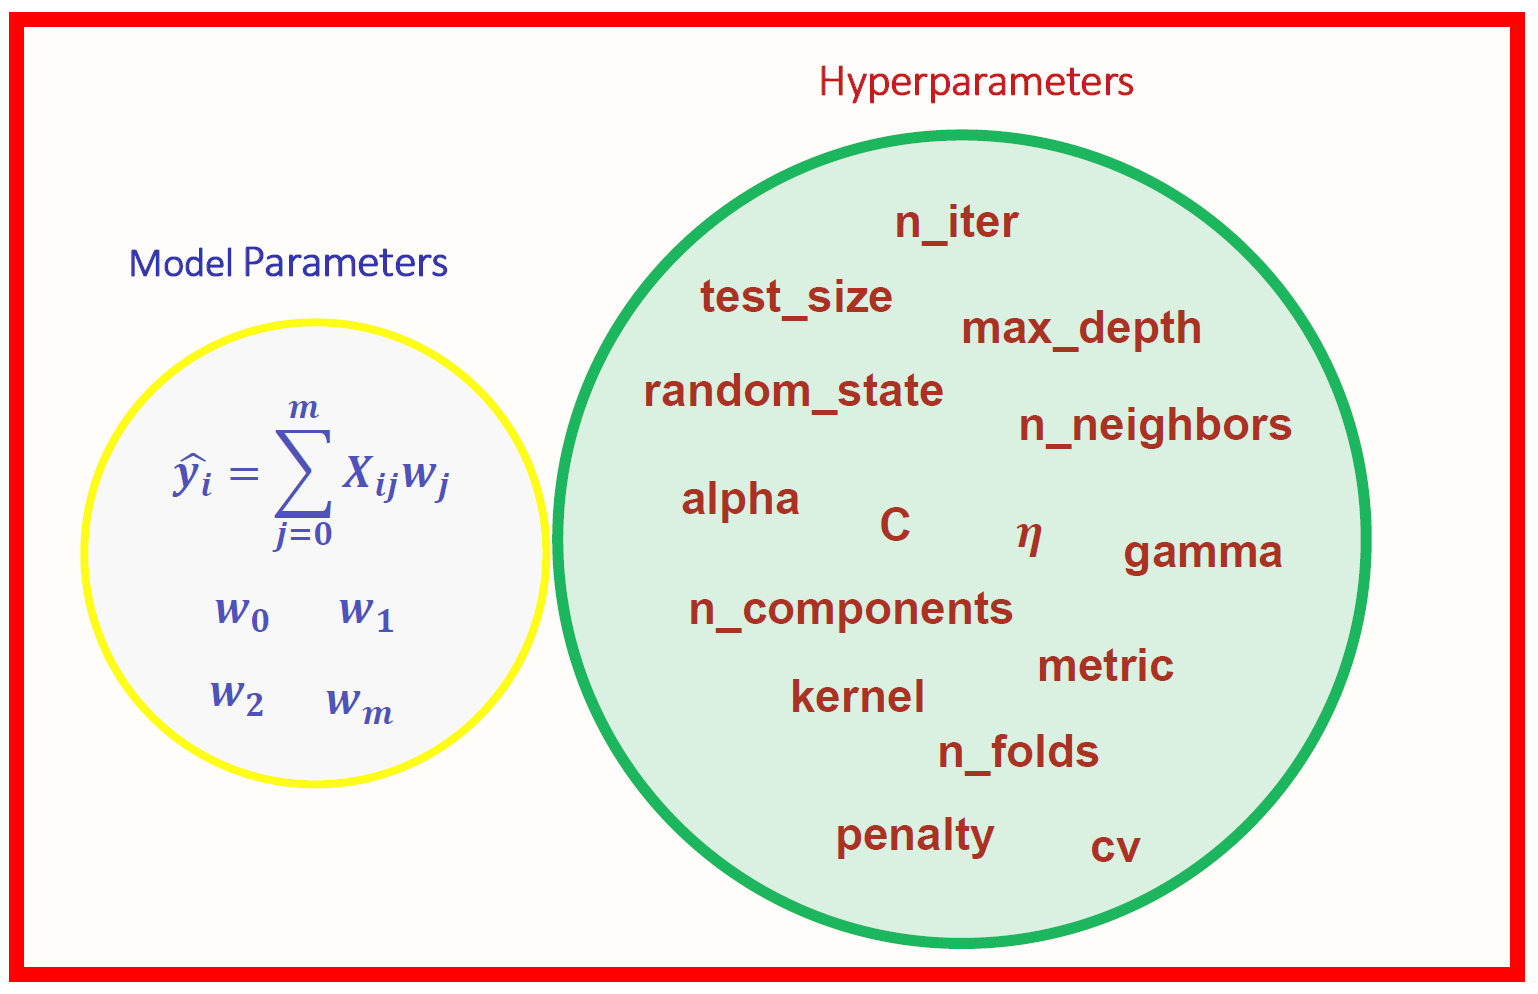

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [ ]:
lasso = Lasso()
parameters = {'alpha': [20],'random_state':[10]}

model = GridSearchCV(lasso, parameters, scoring='neg_mean_squared_error', cv=10)
model.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': [20], 'random_state': [10]},
             scoring='neg_mean_squared_error')

In [ ]:
train_pred = model.predict(x_train)


In [ ]:
test_pred = model.predict(x_test)


In [ ]:
print('Train mean_squared_error :-',mean_squared_error(y_train,train_pred))
print('Train mean_absolute_error :-',mean_absolute_error(y_train,train_pred))
print('Train mean_absolute_percentage_error :-',mean_absolute_percentage_error(y_train,train_pred)*100)
print('Train R2 score ',r2_score(y_train,train_pred))

Train mean_squared_error :- 3280570.816298043
Train mean_absolute_error :- 1347.1242729480462
Train mean_absolute_percentage_error :- 10.955641127581746
Train R2 score  0.9449917877627826


In [ ]:
print('Test mean_squared_error :- ',mean_squared_error(y_test,test_pred))
print('Test mean_absolute_error :-',mean_absolute_error(y_test,test_pred))
print('Test mean_absolute_percentage_error :-',mean_absolute_percentage_error(y_test,test_pred)*100)
print('Test R2 score ',r2_score(y_test,test_pred))

Test mean_squared_error :-  9293638.39196361
Test mean_absolute_error :- 2156.0253677452997
Test mean_absolute_percentage_error :- 18.459549509191074
Test R2 score  0.8822755885954829
